# Analyse Exploratoire

### Import des modules

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Analyse Exploratoire

1) Chargement et présentation des données

In [3]:
building_consumption = pd.read_csv("2016_Building_Energy_Benchmarking.csv")

In [4]:
# On regarde comment un batiment est défini dans ce jeu de données 
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [5]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
building_consumption.info()

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

2) Description des variables

a) Description globale des variables (supposé)

On liste ici les différentes variables et leur signification (supposé) :

1. Identifiants et informations
- #1 - OSEBuildingID : Un identifiant unique attribué à chaque propriété couverte par l'ordonnance de Seattle.
- #2 - DataYear : Année civile de chaque enregistrement de données.
- #3 - BuildingType : Classification des types de bâtiments de haut niveau de la ville de Seattle (Non-résidentiel, Campus, familiale, etc.).
- #5 -  PropertyName : Nom du batiment
- #15 - YearBuilt : L'année de construction. Plus un bâtiment est vieux, plus son isolation est potentiellement datée.


2. Localisation (L'influence géographique)
- #6 - Address : Adresse du bien à Seattle.
- #7 - City : Ville (Seattle partout).
- #8 - State : Etat (Washington partout).
- #9 - Zip Code : Code postal (commence tous par 98).
- #10 - TaxParcelIdentificationNumber : Numéro d'identification de parcelle (PIN) du comté de King.
- #11 - CouncilDistrictCode : Code du district municipal (utile pour des politiques publiques).
- #12 - Neighborhood : Le quartier de Seattle.
- #13/14 - Latitude / Longitude : Coordonnées précises - permettent de voir s'il y a des "clusters" (zones) de forte consommation, en fonction d'une exposition potentielles à des phénomènes climatiques.


3. Informations Structurelles (Les caractéristiques physiques)
- #16 - NumberofBuildings : Le nombre de bâtiments sur la propriété (certains complexes ont plusieurs batiment).
- #17 - NumberofFloors : Le nombre d'étages 'habitales' (à partir du nouveau du sol ou au dessus).
- #18 - PropertyGFATotal : La surface totale (GFA - Gross Floor Area) brute et batiment et du stationnement en pieds carrés.
- #19 - PropertyGFAParking : Surface totale en pieds carrés de tous types de stationnement (entièrement fermé, partiellement fermé et ouvert), mais exclut les surface de batiment (plancher) non dédié au stationnement.
- #20 - PropertyGFABuilding(s) : Surface totale de plancher (en pieds carrés) entre les murs extérieurs d'un bâtiment. Elle comprend toutes les surfaces intérieures (locaux locatifs, parties communes, cages d'escalier, sous-sols, espaces de stockage, etc.), mais exclut le stationnement.

4. Typologie et Usage (L'activité humaine - les usages du batiment)
- #4 - PrimaryPropertyType : L'usage principal déclaré (Hôtel, Bureau, Entrepôt) pour le batiment.
- #21 - ListOfAllPropertyUseTypes : Liste des tous les usages réels occupé par le batiment (sous forme de lite séparé par une virgule).
- #22 - LargestPropertyUseType : Le type d'utilisation du bien le plus important en fonction de la surface brute du bâtiment. Autrement dit, L'usage réel qui occupe la plus grande surface.
- #23 - LargestPropertyUseTypeGFA (sf) : La surface exacte de cet usage principal (LargestPropertyUseType).
- #24 - SecondLargestPropertyUseType :  Le deuxième type d'utilisation de la propriété le plus important en fonction de la surface de plancher brute du bâtiment. Utile pour les bâtiments mixtes (ex: un immeuble de bureaux avec un restaurant au rez-de-chaussée).
- #25 - SecondLargestPropertyUseTypeGFA (sf) : La superficie brute en pieds carrés (sf) de ce second usage.
- #26 - ThirdLargestPropertyUseType :  Le troisième type d'utilisation de la propriété le plus important en fonction de la surface de plancher brute du bâtiment.
- #27 - ThirdLargestPropertyUseTypeGFA (sf) : La superficie brute en pieds carrés (sf) de ce troisème usage.

5. Indicateurs de consommations énergetiques (Cibles - targets potentielles)

    a. Indicateurs spécifiques (par type d'energie).

- #36 - SteamUse(kBtu) : La quantité annuelle de vapeur de réseau consommée par la propriété sur place, mesurée en milliers d'unités thermiques britanniques (kBtu).

- #37 - Electricity(kWh) : 	La quantité annuelle d'électricité consommée par la propriété sur place, y compris l'électricité achetée sur le réseau et produite par les systèmes renouvelables sur place, mesurée en kWh.
- #38 - Electricity(kBtu) : Cette même quantité, exprimé en kBtu.

- #39 - NaturalGas(therms) : La quantité annuelle de gaz naturel fourni par le service public et consommée par la propriété, mesurée en thermies.
- #40 - NaturalGas(kBtu) : Cette même quantité, exprimé en kBtu.

    b. Indicateurs globaux (tout type d'energie confondues).
   
- #34 - SiteEnergyUse(kBtu) : La quantité annuelle d'énergie consommée réellement par la propriété, toutes sources d'énergie confondues. Cible principale de cette étude. Elle est mesurée en milliers (kilos) de BTU British thermal unit. Ce chiffre correspond exactement à la somme des 3 consommations réelles énoncées précedemment : SteamUse(kBtu) + Electricity(kBtu) + NaturalGas(kBtu).
- #35 - SiteEnergyUseWN(kBtu) : Idem, mais Weather Normalized. Elle simule ce qu'aurait été la consommation si l'année avait eu des températures standards : "La consommation énergétique brute normalisée représente la consommation qu'aurait eue le bâtiment dans des conditions climatiques moyennes sur 30 ans".

- #30 - SiteEUI(kBtu/sf) : L'Intensité d'Usage Énergétique (Energy Use Intensity) du site. L'intensité énergétique du site (IES) correspond à la consommation énergétique totale du site d'un bâtiment divisée par sa surface brute. Cela permet de comparer un petit et un grand bâtiment sur une base égale. Elle est mesurée en kBtu par pied carrés (sf - square feet). 
- #31 - SiteEUIWN(kBtu/sf) : Idem, mais Weather Normalized : "L'énergie du site WN correspond à la consommation énergétique du site lors des 30 dernières années, dans des conditions météorologiques moyennes". Elle est mesurée en kBtu par pied carrés (sf - square feet).

- #32 - SourceEUI(kBtu/sf) : L'Intensité d'Usage Énergétique (Energy Use Intensity) de la source. L'intensité d'usage énergétique de la source (IES) correspond à la consommation énergétique d'un bâtiment à la source, divisée par sa surface brute. Contrairement au "Site", elle prend en compte l'énergie perdue lors de la production et du transport (très utile pour l'impact écologique global).
- #33 - SourceEUIWN(kBtu/sf) : Idem, mais Weather Normalized. "La consommation énergétique brute normalisée représente la consommation qu'aurait eue le bâtiment dans des conditions climatiques moyennes sur 30 ans'.

6. Indicateurs de Performance énergetiques
- #28 - YearsENERGYSTARCertified : Année d'attribution de l'ENERGYSTARScore (ci-dessous)
- #29 - ENERGYSTARScore :	L'EPA attribue une note de 1 à 100 qui évalue la performance énergétique globale d'un bâtiment, en se basant sur des données nationales afin de neutraliser les différences liées au climat, à l'usage du bâtiment et à son exploitation (100 est le meilleur).Un score de 50 signifie que le bâtiment est dans la moyenne nationale pour son type.

7. Emissions de Gaz à Effet de Serre
- #45 - TotalGHGEmissions : Les émissions totales de gaz à effet de serre (en tonnes métriques d'équivalent CO2). Cela inclut le dioxyde de carbone, le méthane et l'oxyde nitreux, rejetées dans l'atmosphère du fait de la consommation d'énergie du bâtiment.
- #46 - GHGEmissionsIntensity : Les émissions totales (TotalGHGEmissions) rapportées à la surface brute du batiment (en pieds carrés).

8. Autre
- #41 - DefaultData : Indicateur (vrai/faux) précisant si des données par défaut ont été utilisées à la place de mesures réelles.
- #42 - Comments : Commentaires libres ajoutés lors du relevé.
- #43 - ComplianceStatus : Statut de conformité du bâtiment vis-à-vis de la loi sur le benchmarking  (Compliant/Nom-Compliant/Error - Correct Default Data/Missing Data). Peut-être utilse pour la prédiction de la consommation d'energie (dans le but de discrediter certains batiments). 
- #44 - Outlier : Indicateur signalant si le bâtiment a été identifié comme une valeur aberrante (par la ville).

b) Statistiques sur les variables quantitatives

On donnera les éléments principales de ces variables grâce à la fonction describe(). Cette fonction donne les informations suivantes : 
- nombre d'occurences (ou valeurs présentes), sur 3376 lignes au total.
- la moyenne
- l'écart type (la moyenne des écarts à la moyenne)
- la valeur minimum
- les écarts interquartiles (quel est la valeur pour laquelle 25% des "effectifs" ont en dessous de cette valeur, 50% des effectifs, etc, etc).
- la valeur maximum

In [6]:
# ============================================================
# DESCRIPTION DES VARIABLES QUANTITATIVES
# ============================================================

cols_quantitatives = building_consumption.select_dtypes(include=['number']).columns.tolist()
cols_quantitatives.remove("ZipCode")
cols_quantitatives.remove("CouncilDistrictCode")
cols_quantitatives.remove("OSEBuildingID")
cols_quantitatives.remove("Comments")
print(f"{len(cols_quantitatives)} colonnes numériques\n")

building_consumption[cols_quantitatives].describe().T.round(2)

26 colonnes numériques



,count,mean,std,min,25%,50%,75%,max
DataYear,3376.0,2016.00,0.00,2016.00,2016.00,2016.00,2016.00,2.016000e+03
Latitude,3376.0,47.62,0.05,47.50,47.60,47.62,47.66,4.773000e+01
Longitude,3376.0,-122.33,0.03,-122.41,-122.35,-122.33,-122.32,-1.222200e+02
YearBuilt,3376.0,1968.57,33.09,1900.00,1948.00,1975.00,1997.00,2.015000e+03
NumberofBuildings,3368.0,1.11,2.11,0.00,1.00,1.00,1.00,1.110000e+02
NumberofFloors,3376.0,4.71,5.49,0.00,2.00,4.00,5.00,9.900000e+01
PropertyGFATotal,3376.0,94833.54,218837.61,11285.00,28487.00,44175.00,90992.00,9.320156e+06
PropertyGFAParking,3376.0,8001.53,32326.72,0.00,0.00,0.00,0.00,5.126080e+05
PropertyGFABuilding(s),3376.0,86832.01,207939.81,3636.00,27756.00,43216.00,84276.25,9.320156e+06
LargestPropertyUseTypeGFA,3356.0,79177.64,201703.41,5656.00,25094.75,39894.00,76200.25,9.320156e+06


c) Statistiques des variables qualitatives

On décrit chaque variables en lisant ses modalités et le nombre d'occurences de chacune de ses modalités

In [7]:
# ============================================================
# DESCRIPTION DES VARIABLES QUALITATIVES (CATÉGORIELLES)
# ============================================================

cols_qualitatives = building_consumption.select_dtypes(include=['object', 'str']).columns.tolist()
cols_qualitatives.append("ZipCode")
cols_qualitatives.append("CouncilDistrictCode")
cols_qualitatives.append("OSEBuildingID")
cols_qualitatives.append("Comments")
cols_qualitatives.append("DefaultData")
print(f"{len(cols_qualitatives)} colonnes catégorielles\n")

SEUIL_PCT = 5  # n'affiche que les modalités >= 5% de l'effectif

for col in cols_qualitatives:
    n_unique = building_consumption[col].nunique()
    counts = building_consumption[col].value_counts()
    top = counts[counts / len(building_consumption) * 100 >= SEUIL_PCT]
    
    print(f"── {col} ({n_unique} valeurs uniques)")
    for val, count in top.items():
        pct = count / len(building_consumption) * 100
        print(f"   {val} : {count} occurrences ({pct:.1f}%)")
    if len(top) == 0:
        print("   (aucune modalité ne dépasse le seuil)")
    print()

#Cette partie permettant de lister les 3 modalités les plus représentées en terme d'occurence de
#chacun des colonnes qualitatives 

"""
for col in cols_qualitatives:
    n_unique = building_consumption[col].nunique()
    top3 = building_consumption[col].value_counts().head(3).to_dict()
    #items = building_consumption[col].value_counts().to_dict()
    print(f"── {col} ({n_unique} valeurs uniques)")
    for val, count in top3.items():
    #for val, count in items.items():
        print(f"   {val!r:<45} {count} occurrences")
    print()

"""

20 colonnes catégorielles

── BuildingType (8 valeurs uniques)
   NonResidential : 1460 occurrences (43.2%)
   Multifamily LR (1-4) : 1018 occurrences (30.2%)
   Multifamily MR (5-9) : 580 occurrences (17.2%)

── PrimaryPropertyType (24 valeurs uniques)
   Low-Rise Multifamily : 987 occurrences (29.2%)
   Mid-Rise Multifamily : 564 occurrences (16.7%)
   Small- and Mid-Sized Office : 293 occurrences (8.7%)
   Other : 256 occurrences (7.6%)
   Warehouse : 187 occurrences (5.5%)
   Large Office : 173 occurrences (5.1%)

── PropertyName (3362 valeurs uniques)
   (aucune modalité ne dépasse le seuil)

── Address (3354 valeurs uniques)
   (aucune modalité ne dépasse le seuil)

── City (1 valeurs uniques)
   Seattle : 3376 occurrences (100.0%)

── State (1 valeurs uniques)
   WA : 3376 occurrences (100.0%)

── TaxParcelIdentificationNumber (3268 valeurs uniques)
   (aucune modalité ne dépasse le seuil)

── Neighborhood (19 valeurs uniques)
   DOWNTOWN : 573 occurrences (17.0%)
   EAST : 453 

'\nfor col in cols_qualitatives:\n    n_unique = building_consumption[col].nunique()\n    top3 = building_consumption[col].value_counts().head(3).to_dict()\n    #items = building_consumption[col].value_counts().to_dict()\n    print(f"── {col} ({n_unique} valeurs uniques)")\n    for val, count in top3.items():\n    #for val, count in items.items():\n        print(f"   {val!r:<45} {count} occurrences")\n    print()\n\n'

3) Filtrage des données

    a. Filtrage des lignes

        1. BuildingType

On va désormais filtrer une partie des lignes en supprimant les batiments qui sont résidentiels. En effet l'étude s'intéresse aux batiments non résidentiels donc pas de raisons de conserver les autres. Pour faire cela, on va déjà determiner les types de batiment et par extension, ceux qui ne concernent pas des batiments résidentiels. 

In [8]:
colums_BuildingType = building_consumption['BuildingType'].unique()
for c in colums_BuildingType:
        print(c)

NonResidential
Nonresidential COS
Multifamily MR (5-9)
SPS-District K-12
Campus
Multifamily LR (1-4)
Multifamily HR (10+)
Nonresidential WA


On peut statuer avec certitude que les modalités 'Multifamily LR (1-4)', 'Multifamily MR (5-9)' et 'Multifamily HR (10+)' concerne des batiments résidentiels, de par leurs noms explicites. Par conséquent, nous allons procéder à leur suppresssion dans le dataframe. Pour les autres nous ne sommes pas surs donc on va les garder pour l'instant.

In [9]:
# ============================================================
# FILTRAGE — Bâtiments non résidentiels uniquement
# ============================================================

len_before_filtering_1 = len(building_consumption)
print(f"Lignes initiales : {len_before_filtering_1}")

# On garde uniquement les bâtiments non destinés à l'habitation
# Les types Multifamily (LR/MR/HR) sont des immeubles résidentiels → hors scope de l'étude
types_to_exclude = ['Multifamily LR (1-4)', 'Multifamily MR (5-9)', 'Multifamily HR (10+)']

filtered_1_building_consumption = building_consumption[~building_consumption['BuildingType'].isin(types_to_exclude)]

len_after_filtering_1 = len(filtered_1_building_consumption)
print(f"Après filtrage résidentiel : {len_after_filtering_1} bâtiments")


Lignes initiales : 3376
Après filtrage résidentiel : 1668 bâtiments


In [10]:
colums_BuildingType = filtered_1_building_consumption['BuildingType'].unique()
for c in colums_BuildingType:
        print(c)

NonResidential
Nonresidential COS
SPS-District K-12
Campus
Nonresidential WA


        2. Outlier

Très clairement la colonne 'Outlier' permet de déterminer des batiments abérrants car ce terme signie 'Valeur aberrante' en anglais. On va donc commencer par procéder à la suppression de ces lignes.

In [11]:
len_before_filtering_2 = len(filtered_1_building_consumption)
print(f"Lignes initiales : {len_before_filtering_2}")
filtered_2_building_consumption = filtered_1_building_consumption[filtered_1_building_consumption['Outlier'].isna()]
len_after_filtering_2 = len(filtered_2_building_consumption)
print(f"Après deuxième filtrage (outlier) : {len_after_filtering_2}")

Lignes initiales : 1668
Après deuxième filtrage (outlier) : 1651


        3. SiteEnergyUse(kBtu)

In [12]:
# Suppression des consommations nulles ou négatives (incohérent pour un bâtiment actif)
print(f"Lignes initiales : {len_after_filtering_2}")
filtered_3_building_consumption = filtered_2_building_consumption[filtered_2_building_consumption['SiteEnergyUse(kBtu)'] > 0]
len_after_filtering_3 = len(filtered_3_building_consumption)
print(f"Après troisième filtrage (outlier) : {len_after_filtering_3}")

Lignes initiales : 1651
Après troisième filtrage (outlier) : 1633


    b. Filtrage des colonnes

        1. Taux de valeurs manquantes elevés : Outlier/Comments/YearsENERGYSTARCertified --> -3 variables

On va désormais regarder le nombre de valeurs manquantes par colonne :

In [13]:
# Valeurs manquantes par colonne
missing = pd.DataFrame({
    'nb_manquantes': filtered_2_building_consumption.isnull().sum(),
    'taux (%) de valeurs manquantes': (filtered_2_building_consumption.isnull().sum() / len(filtered_2_building_consumption) * 100).round(2)
})
missing = missing.sort_values('taux (%) de valeurs manquantes', ascending=False)
print(missing)

                                 nb_manquantes  taux (%) de valeurs manquantes
Outlier                                   1651                          100.00
Comments                                  1651                          100.00
YearsENERGYSTARCertified                  1553                           94.06
ThirdLargestPropertyUseType               1300                           78.74
ThirdLargestPropertyUseTypeGFA            1300                           78.74
SecondLargestPropertyUseType               803                           48.64
SecondLargestPropertyUseTypeGFA            803                           48.64
ENERGYSTARScore                            568                           34.40
ZipCode                                     16                            0.97
LargestPropertyUseType                       6                            0.36
LargestPropertyUseTypeGFA                    6                            0.36
SiteEUI(kBtu/sf)                             3      

En fonction de ces résultats, on va supprimer 3 colonnes qui n'apportent aucune information (ou quasiment pas) :
- Outlier : Etant donné que l'on a supprimé les lignes (batiments) marquées comme 'Outlier' à l'aide d'un booléen (true/false), cette colonne comporte 100% de valeurs manquantes.
- Comments : 100% de valeurs manquantes par défaut. 
- YearsENERGYSTARCertified : Année de certification du score Energy Star. Beaucoup de valeurs manquantes et peu intéressant dans le cadre de notre projet. 

In [14]:
# Liste des colonnes à supprimer
cols_to_drop = [
    'Comments', 
    'YearsENERGYSTARCertified', 
    'Outlier'
]

filtered_4_building_consumption = filtered_3_building_consumption.drop(columns=cols_to_drop)
print(f"Nombre de colonnes restantes : {filtered_4_building_consumption.shape[1]}")
filtered_4_building_consumption.head()

Nombre de colonnes restantes : 43


,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,Compliant,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,Compliant,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,Compliant,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,Compliant,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,Compliant,505.01,2.88


        2. Variance nulle : DataYear/City/State --> -3 variables

On aurait également pu supprimer d'autres colonnes car elles ne présente aucune variance dans la mesure où elles ont la même valeur partout :
- DataYear : 2016 partout.
- City : Seattle partout.
- State : WA (washington) partout.

Nous allons en profiter pour le faire dans le cadre de ce projet afin d'alleger le modèle de prédiction.

In [15]:
# Liste des colonnes à supprimer
cols_to_drop = [
    'DataYear', 
    'City', 
    'State'
]

filtered_5_building_consumption = filtered_4_building_consumption.drop(columns=cols_to_drop)
print(f"Nombre de colonnes restantes : {filtered_5_building_consumption.shape[1]}")

Nombre de colonnes restantes : 40


On affiche un extrait du résultat de ces filtrages.

In [16]:
filtered_5_building_consumption.head()

,OSEBuildingID,BuildingType,PrimaryPropertyType,PropertyName,Address,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,...,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
0,1,NonResidential,Hotel,Mayflower park hotel,405 Olive way,98101.0,0659000030,7,DOWNTOWN,47.61220,...,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,Compliant,249.98,2.83
1,2,NonResidential,Hotel,Paramount Hotel,724 Pine street,98101.0,0659000220,7,DOWNTOWN,47.61317,...,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,Compliant,295.86,2.86
2,3,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,98101.0,0659000475,7,DOWNTOWN,47.61393,...,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,Compliant,2089.28,2.19
3,5,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,98101.0,0659000640,7,DOWNTOWN,47.61412,...,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,Compliant,286.43,4.67
4,8,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,98121.0,0659000970,7,DOWNTOWN,47.61375,...,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,Compliant,505.01,2.88


        3. Pertinence ou Cohérence dans le cadre de l'étude.

Pour des raisons différentes, on peut supprimer certaines colonnes qui n'ont pas de pertinence pour l'objectif de l'étude : prédire les consommations d'energie des batiments.

            a. Identifiants uniques (non caractéristiques) --> Pertinence --> -4 variables

Ces colonnes ne renseignent pas sur des caractéristiques que l'on pourrait retrouver sur d'autres batiments afin d'en tirer des conclusions générales. Au contraire, ils renseignent
sur des identifiants qui ne concernent que les batiments correspondent et il est impossible d'extrapoler des prédictions à partir de ces informations.
Ces colonnes sont les suivantes : 
- OSEBuildingID : Aucune information utile pour prédire la consommation en energie.
- PropertyName: Même raison que précedemment. 
- Address : Identifiant unique qui ne renseigne pas vraiment sur la localisation, ou de manière trop précise pour en tirer des conclusions sur la consommation en energie.
- TaxParcelIdentificationNumber : Même raison que précedemment. 

In [17]:
# Liste des colonnes à supprimer
cols_to_drop = [
    'OSEBuildingID', 
    'PropertyName', 
    'Address',
    'TaxParcelIdentificationNumber'
]

filtered_6_building_consumption = filtered_5_building_consumption.drop(columns=cols_to_drop)
print(f"Nombre de colonnes restantes : {filtered_6_building_consumption.shape[1]}")

Nombre de colonnes restantes : 36


            b. Data leakage : Composantes de la target --> Cohérence --> -5 variables

Certaines colonnes comme SiteEUI, Electricity, NaturalGas, SteamUse sont des composantes de notre cible SiteEnergyUse. Elles ont en effet permis de calculer notre cible de la façon suivante : SiteEnergyUse = Electricity(kBtu) + NaturalGas(kBtu) + SteamUse(kBtu). Si on les laissait dans le modèle, il tricherait en utilisant des informations qu'il n'aurait pas en production — et on obtiendrait des performances artificiellement parfaites. Ces variables sont les suivantes :
- Electricity(kWh) : Composante de la cible — leakage.
- Electricity(kBtu) : Même composante, dans une autre autre unité.
- NaturalGas(therms) : Composante de la cible — leakage.
- NaturalGas(kBtu) : Même composante, dans une autre unité.
- SteamUse(kBtu) : Composante de la cible. 

In [18]:
# Liste des colonnes à supprimer
cols_to_drop = [
    'Electricity(kWh)', 
    'Electricity(kBtu)', 
    'NaturalGas(therms)',
    'NaturalGas(kBtu)',
    'SteamUse(kBtu)'
]

filtered_7_building_consumption = filtered_6_building_consumption.drop(columns=cols_to_drop)
print(f"Nombre de colonnes restantes : {filtered_7_building_consumption.shape[1]}")

Nombre de colonnes restantes : 31


            c. Data leakage : Version dérivées de la target --> Cohérence --> -5 variables 

De la même manière que précedemment, certaines colonnes sont des dérivées de notre target SiteEnergyUse. C'est à dire qu'elles sont issues de modifications directement apportées à SiteEnergyUse. Le modèle pourrait donc également tricher en utilisant ces informations dérivées pour retrouver notre cible de manière exacte. Cela ne nous aiderait pas à produire un modèle robuste qui, à partir de données réelles et constatés, determinerait la consommation energetiques de ces batiments. En effet, lors d'une prévisions sur des nouveaux batiments, nous ne connaitrions à priori pas ces variables, nous ne pouvons donc pas les choisir comme base de notre modèle. 
- SiteEUI(kBtu/sf) : Dérivé de la cible (SiteEnergyUse).
- SiteEUIWN(kBtu/sf) : Idem, version weather-normalized.
- SourceEUI(kBtu/sf) :	Dérivé de la cible (SiteEnergyUse).
- SourceEUIWN(kBtu/sf) : 	Idem, version weather-normalized.
- SiteEnergyUseWN(kBtu) : Version normalisée (weather-normalized) de notre target. On aurait également pu choisir cette variable comme target. Cependant elle ne correspond pas à la valeur réelle constaté mais elle-aussi à une prédiction en cas de conditions météorologique normales. On ne prédit donc pas une prédiction. 

In [19]:
# Liste des colonnes à supprimer
cols_to_drop = [
    'SiteEUI(kBtu/sf)', 
    'SiteEUIWN(kBtu/sf)', 
    'SourceEUI(kBtu/sf)',
    'SourceEUIWN(kBtu/sf)',
    'SiteEnergyUseWN(kBtu)'
]

filtered_8_building_consumption = filtered_7_building_consumption.drop(columns=cols_to_drop)
print(f"Nombre de colonnes restantes : {filtered_8_building_consumption.shape[1]}")

Nombre de colonnes restantes : 26


        4. Redondances des données : corrélations fortes entre les variables. 

Si deux variables ont une très fortes corrélations (au dessus de 0.9), il est possible de supprimer une des deux variables. Pour choisir celles qui sera supprimée, il est necessaire
de les recontextualiser dans le cadre de l'étude : Quelle est la variable la plus suceptible de prédire les données ou celle qui est le plus suceptible d'être une cible (target).
En fonction de la réponse, l'autre variable pourra être supprimé sans perdre une quantité d'information et sans remettre en cause l'objet du projet. 

            a. Emission de Gaz (TotalGHGEmissions) et Consommation d'energie (SiteEnergyUse(kBtu) --> -1 variable

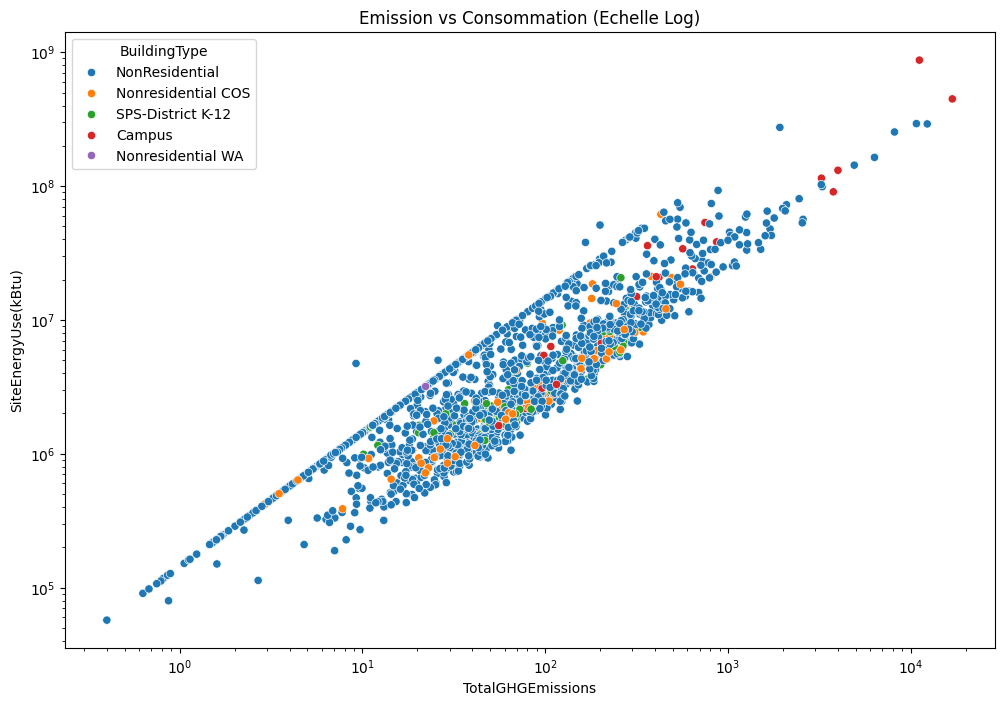

In [20]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=filtered_8_building_consumption, x='TotalGHGEmissions', y='SiteEnergyUse(kBtu)', hue='BuildingType')
plt.xscale('log')
plt.yscale('log')
plt.title('Emission vs Consommation (Echelle Log)')
plt.show()

Les deux variables sont effectivement très corrélés. On peut même se demande si la variable TotalGHGEmissions n'a pas été calculée sur la base de la consommation en énergie. Sinon comment aurait-on pu obtenir ces informations ? Jusqu'à preuve du contraire, on ne peut pas mesurer de manière réelle la quantité de gaz émise par une batiment.

Dans le cadre de notre étude, celle qui nous intéresse est clairement 'SiteEnergyUse(kBtu)' qui correspond à la consommation d'energie (en kBtu - kilobtus) de chaque batiment. Nous retiendrons donc 'SiteEnergyUse(kBtu)' et nous pouvons écarter TotalGHGEmissions. 

            b. Intensite des emissions (GHGEmissionsIntensity) et Consommation d'energie (SiteEnergyUse(kBtu) --> -1 variable

La variable GHGEmissionsIntensity étant dérivée de TotalGHGEmissions (en la rapportant par la surface), il y a également une redondance de données entre les deux variables.
On pourrait donc retrouver TotalGHGEmissions en multipliant GHGEmissionsIntensity par la surface, que l'on a gardé dans notre modèle. Cela reviendrait donc à garder TotalGHGEmissions que l'on a décidé de supprimer pour redondance de données.
--> On supprime donc également cette variable (GHGEmissionsIntensity) pour les mêmes raisons.

            c. Redondance entre Neighborhood (Quartier - 19 valeurs), ZipCode (Code Postal - 55 valeurs) et CouncilDistrictCode (Code District - 7 valeurs) --> -2 variables

Ces 3 variables donne des indications sur la localisation du batiment. De différentes manières :

- CouncilDistrictCode (Code du district administratif) : Avec 7 valeurs numérique, le code du district indique davantage une division politique/administrative. Bien qu'utile pour la mairie, elle n'a pas d'influence physique sur la consommation d'énergie d'un bâtiment. La météo ou l'âge des bâtiments ne s'arrêtent pas à la frontière d'un district du conseil municipal.

- Neighborhood (Quartier) : la Zone de voisinage, définie par le département des quartiers de la ville de Seattle, détermine veritablement une zone géographique. Avec 19 modalités sans aucun 'NaN' offre une granularité suffisante tout en garantissant que chaque quartier est bien représenté dans les données. De plus, il s'agit d'une variable "categorielle" sur laquelle le modèle peut apprendre facilement, sans transformations préalable.

- ZipCode (Code postal) : Même s'il est composé de chiffres, c'est bien une variable qualitative. Il renseigne également sur la localisation du batiment, au même titre que le Neighborhood. Cependant, il faudra donc le traiter en one-hot encoding comme n'importe quelle variable catégorielle sous forme de nombre. Avec 48 modalités, le one-hot encoding de ZipCode va créer 48 colonnes binaires dans la matrice. Avec seulement 1 649 bâtiments, certains ZipCodes auront très peu de représentants — quelques bâtiments par code postal — ce qui rend difficile pour le modèle d'apprendre un signal fiable sur ces modalités rares (problème de la sous-représentation).



On va vérifier la réprésentativité de chacune des variables pour voir celles qui a le plus de modalités "sous-représentés" c'est à dire avec moins de 10 individus associés.

In [21]:
# Vérifier la représentativité de chaque ZipCode
print(filtered_8_building_consumption['ZipCode'].value_counts())
print(f"\nNb de ZipCodes avec moins de 10 bâtiments : "
      f"{(filtered_8_building_consumption['ZipCode'].value_counts() < 10).sum()}\n\n")

print(filtered_8_building_consumption['Neighborhood'].value_counts())
print(f"\nNb de Neighborhoods avec moins de 10 bâtiments : "
      f"{(filtered_8_building_consumption['Neighborhood'].value_counts() < 10).sum()}")

ZipCode
98134.0    180
98104.0    155
98101.0    145
98109.0    138
98108.0    119
98122.0     89
98121.0     83
98105.0     83
98103.0     67
98119.0     62
98125.0     51
98115.0     50
98107.0     49
98133.0     49
98118.0     46
98144.0     46
98102.0     26
98106.0     25
98116.0     24
98199.0     21
98126.0     21
98112.0     20
98117.0     18
98195.0      9
98136.0      6
98155.0      4
98178.0      3
98154.0      2
98111.0      2
98168.0      2
98124.0      2
98013.0      2
98146.0      2
98177.0      2
98070.0      1
98033.0      1
98191.0      1
98164.0      1
98185.0      1
98181.0      1
98006.0      1
98053.0      1
98114.0      1
98165.0      1
98011.0      1
98113.0      1
98020.0      1
98145.0      1
Name: count, dtype: int64

Nb de ZipCodes avec moins de 10 bâtiments : 25


Neighborhood
DOWNTOWN                  354
GREATER DUWAMISH          342
LAKE UNION                147
MAGNOLIA / QUEEN ANNE     147
NORTHEAST                 125
EAST                      120
NOR

Zip Code est clairement la variable la plus mal représentée avec 25 variables associée à moins de 10 batiments, contre 6 pour la variable Neighborhood. On écarte donc Zip Code au profit de Neighborhood.

On décide donc (plus ou moins arbitrairement) de supprimer les variable 'CouncilDistrictCode' et 'ZipCode' pour ne laisser que 'Neighborhood' ainsi que longitude et latitude car il renseigne sur la position exacte.

In [22]:
# Liste des colonnes à supprimer
cols_to_drop = [
    'TotalGHGEmissions', 
    'GHGEmissionsIntensity', 
    'CouncilDistrictCode',
    'ZipCode'
]

filtered_9_building_consumption = filtered_8_building_consumption.drop(columns=cols_to_drop)
print(f"Nombre de colonnes restantes : {filtered_9_building_consumption.shape[1]}")

Nombre de colonnes restantes : 22


        c. Filtrages complémentaires

On regarde désormais les colonnes restantes et le nombre de valeurs manquantes par colonne :

In [23]:
# Valeurs manquantes par colonne
missing = pd.DataFrame({
    'nb_manquantes': filtered_9_building_consumption.isnull().sum(),
    'taux (%) de valeurs manquantes': (filtered_9_building_consumption.isnull().sum() / len(filtered_9_building_consumption) * 100).round(2)
})
missing = missing.sort_values('taux (%) de valeurs manquantes', ascending=False)
print(missing)

                                 nb_manquantes  taux (%) de valeurs manquantes
ThirdLargestPropertyUseTypeGFA            1282                           78.51
ThirdLargestPropertyUseType               1282                           78.51
SecondLargestPropertyUseTypeGFA            786                           48.13
SecondLargestPropertyUseType               786                           48.13
ENERGYSTARScore                            551                           33.74
LargestPropertyUseType                       4                            0.24
LargestPropertyUseTypeGFA                    4                            0.24
Longitude                                    0                            0.00
YearBuilt                                    0                            0.00
Neighborhood                                 0                            0.00
PrimaryPropertyType                          0                            0.00
BuildingType                                 0      

            1. Variables 'DefaultData' et 'ComplianceStatus'

                a. Lignes associées aux valeurs 'true' et 'ComplianceStatus'

Pour rappel, les variables Default Data et Compliance Status ont les descriptions suivantes : 
- DefaultData est un flag booléen qui indique que les données du bâtiment sont des valeurs par défaut estimées par la ville, et non des relevés réels. 'True' si c'est le cas, 'False' dans le cas contraire.
- ComplianceStatus : Statut de conformité du bâtiment vis-à-vis de la loi sur le benchmarking (Compliant/Nom-Compliant/Error - Correct Default Data/Missing Data). 'Compliant' si un immeuble respecte les exigences de référence en matière d'énergie pour l'année de déclaration spécifiée. 'Error - Correct Default Data' si les données n'ont pas permi d'obtenir ce statut.

Voyons les occurences de ces valeurs pour chacune de ces variables. 

In [24]:
print(filtered_8_building_consumption['DefaultData'].value_counts())
print(filtered_8_building_consumption['ComplianceStatus'].value_counts())

DefaultData
False    1548
True       85
Name: count, dtype: int64
ComplianceStatus
Compliant                       1548
Error - Correct Default Data      85
Name: count, dtype: int64


Voyons maintenant si les valeurs de ces variables sont corrélés pour détecter une éventuelle signification et redondance de données. 

In [25]:
# Vérification de la redondance
print(pd.crosstab(filtered_9_building_consumption['DefaultData'], filtered_9_building_consumption['ComplianceStatus']))

ComplianceStatus  Compliant  Error - Correct Default Data
DefaultData                                              
False                  1548                             0
True                      0                            85


Les valeurs à True pour la variable DefaultData concernent exactement les mêmes lignes (individus) que celles à 'Error - Correct Default Data' pour la variable ComplianceStatus. Cela signifie que ces lignes sont bien concernés par un problème de données qui peut poser problème dans notre modèle de par prédiction. De par le faible nombre de ces individus, nous pouvons tout simplement les supprimer.

In [26]:
# Suppression des consommations nulles ou négatives (incohérent pour un bâtiment actif)
len_filtered_9_building_consumption = len(filtered_9_building_consumption)
print(f"Lignes initiales : {len_filtered_9_building_consumption}")
filtered_10_building_consumption = filtered_9_building_consumption[filtered_9_building_consumption['DefaultData'] == False]
#On aurait également filtrer sur la colonne ComplianceStatus car les deux variables sont 100% corrélés sur ces modalités
#filtered_10_building_consumption = filtered_9_building_consumption[filtered_9_building_consumption['ComplianceStatus'] = 'Error - Correct Default Data']
len_filtered_10_building_consumption = len(filtered_10_building_consumption)
print(f"Après diziaine filtrage (DefaultData - False) : {len_filtered_10_building_consumption}")

Lignes initiales : 1633
Après diziaine filtrage (DefaultData - False) : 1548


                b. Colonnes associés aux variables DefaultData et ComplianceStatus --> -2 variables

Etant donné que l'on a supprimé les modalités 'False' et 'Error - Correct Default Data' des variables DefaultData et ComplianceStatus, il ne reste plus qu'une modalité pour chacune des deux variables soit une variance nulle. Par conséquent, on peut supprimer ces deux variables.

In [27]:
# Liste des colonnes à supprimer
cols_to_drop = [
    'DefaultData', 
    'ComplianceStatus', 
]

filtered_11_building_consumption = filtered_10_building_consumption.drop(columns=cols_to_drop)
print(f"Nombre de colonnes restantes : {filtered_11_building_consumption.shape[1]}")

Nombre de colonnes restantes : 20


                    c. Colonne 'ListOfAllPropertyUseTypes'

Même si cette colonne semble pertinente, elle n'est pas adaptée dans le cadre de notre modèle de prédiction. En effet c'est une chaîne de caractères brute (ex: "Hotel, Restaurant, Parking"). Pour un modèle de ML, c'est inexploitable tel quel. Dans la mesure où l'on a déjà les colonnes LargestPropertyUseType, Second..., etc., cette liste n'apporte aucune information structurée supplémentaire. Nous pouvons donc la supprimer. 

In [28]:
cols_to_drop = [
    'ListOfAllPropertyUseTypes'
]

filtered_12_building_consumption = filtered_11_building_consumption.drop(columns=cols_to_drop)
print(f"Nombre de colonnes restantes : {filtered_12_building_consumption.shape[1]}")

Nombre de colonnes restantes : 19


On regarde désormais les colonnes restantes le nombre et le taux de valeurs manquantes associées.

In [29]:
# Valeurs manquantes par colonne
missing = pd.DataFrame({
    'nb_manquantes': filtered_12_building_consumption.isnull().sum(),
    'taux (%) de valeurs manquantes': (filtered_12_building_consumption.isnull().sum() / len(filtered_12_building_consumption) * 100).round(2)
})
missing = missing.sort_values('taux (%) de valeurs manquantes', ascending=False)
print(missing)

                                 nb_manquantes  taux (%) de valeurs manquantes
ThirdLargestPropertyUseType               1200                           77.52
ThirdLargestPropertyUseTypeGFA            1200                           77.52
SecondLargestPropertyUseType               706                           45.61
SecondLargestPropertyUseTypeGFA            706                           45.61
ENERGYSTARScore                            551                           35.59
LargestPropertyUseType                       4                            0.26
LargestPropertyUseTypeGFA                    4                            0.26
Neighborhood                                 0                            0.00
PrimaryPropertyType                          0                            0.00
BuildingType                                 0                            0.00
Latitude                                     0                            0.00
PropertyGFABuilding(s)                       0      

In [138]:
print(filtered_12_building_consumption.columns)

Index(['BuildingType', 'PrimaryPropertyType', 'Neighborhood', 'Latitude',
       'Longitude', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors',
       'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
       'ENERGYSTARScore', 'SiteEnergyUse(kBtu)'],
      dtype='str')


4. Visualisations pertinentes (après filtrage)

Après ces différents filtrages, il peut intéressant d'observer la distribution de certaines variables ou la correlations de plusieurs variables entre elles. Cela s'opère sur une effectif réduit d'individus et donne plus de sens aux différentes différentes représentations obtenus sur ces graphiques. 

    a. La distribution (du logarithme naturel) de la consommation énergetique (cible)

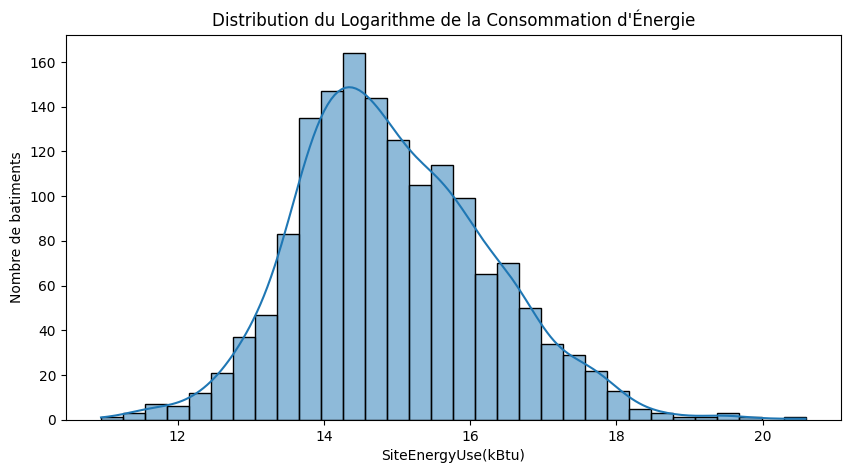

In [33]:
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(filtered_12_building_consumption['SiteEnergyUse(kBtu)']), kde=True)
plt.ylabel("Nombre de batiments")
#sns.histplot(filtered_5_building_consumption['SiteEnergyUse(kBtu)'], kde=True)
plt.title('Distribution du Logarithme de la Consommation d\'Énergie')
plt.show()

    b. Relations entre Surface et Consommation par type de bâtiment, normalisé par le logarithme.

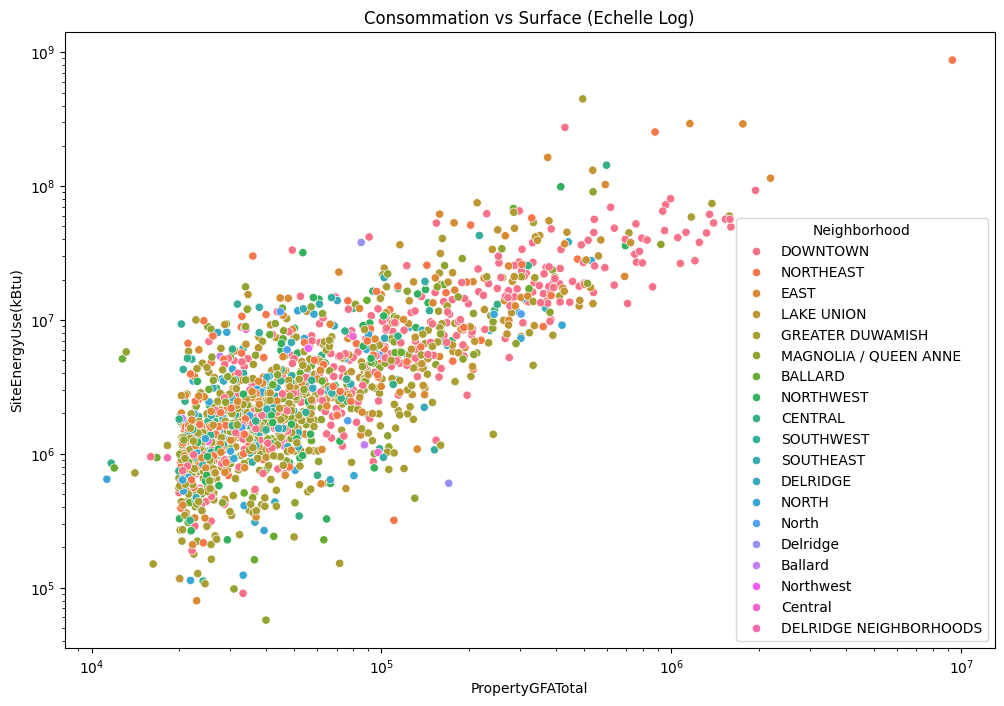

In [34]:
plt.figure(figsize=(12, 8))
#sns.scatterplot(data=filtered_5_building_consumption, x='PropertyGFATotal', y='SiteEnergyUse(kBtu)', hue='BuildingType')
sns.scatterplot(data=filtered_12_building_consumption, x='PropertyGFATotal', y='SiteEnergyUse(kBtu)', hue='Neighborhood')
plt.xscale('log')
plt.yscale('log')
plt.title('Consommation vs Surface (Echelle Log)')
plt.show()

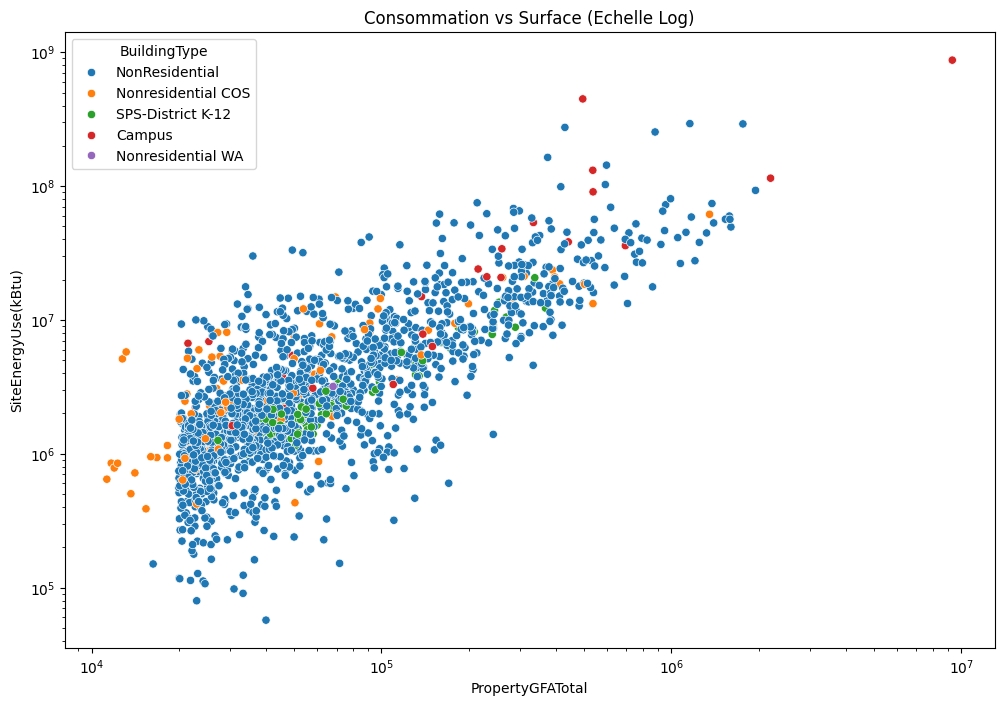

In [35]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=filtered_5_building_consumption, x='PropertyGFATotal', y='SiteEnergyUse(kBtu)', hue='BuildingType')
plt.xscale('log')
plt.yscale('log')
plt.title('Consommation vs Surface (Echelle Log)')
plt.show()

# Modélisation 

### Import des modules 

In [ ]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


### Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

In [ ]:
# CODE FEATURE ENGINEERING

### Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation.
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne.

In [ ]:
# CODE PREPARATION DES FEATURES

### Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

In [1]:
# CODE COMPARAISON DES MODELES

### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn. 

In [ ]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE